In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Cell 0 — Environment Setup

This cell sets up the environment required to run MiniRocket on Kaggle.

We clone the original MiniRocket repository directly from the paper 
author's GitHub (angus924), install the `aeon` library for loading 
UCR datasets, and verify that Numba, NumPy and scikit-learn are 
available at compatible versions.

**Key dependencies:**
- `aeon` — loads UCR benchmark datasets automatically
- `numba` — compiles MiniRocket's transform functions for fast execution
- `sklearn` — provides the Ridge classifier used for classification

In [2]:
#cell 0-Installing all dependencies and clonning MiniRocket

!pip install -q aeon 
!git clone https://github.com/angus924/minirocket.git /kaggle/working/minirocket_repo

import sys
sys.path.insert(0, "/kaggle/working/minirocket_repo/code")

# Verify environment
import numba, numpy, sklearn
print(f"Numba  : {numba.__version__}")
print(f"NumPy  : {numpy.__version__}")
print(f"sklearn: {sklearn.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 45.3 MB/s eta 0:00:00
Cloning into '/kaggle/working/minirocket_repo'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 109 (delta 17), reused 14 (delta 14), pack-reused 85 (from 1)
Receiving objects: 100% (109/109), 44.58 KiB | 1.65 MiB/s, done.
Resolving deltas: 100% (39/39), done.
Numba  : 0.60.0
NumPy  : 2.0.2
sklearn: 1.6.1


##Cell 1 -LOADING A UCR BENCHMARK DATASET 

Time series classification reasearch relies on the **UCR ARCHIVE ** and its is a standardised collection of 128 real-world datasets maintained by University of California Riverside .Every dataset in the archive provides a fixed train/test split, ensuring 
that all algorithms are evaluated under identical conditions and results are 
directly comparable across papers.

We begin with the **GunPoint** dataset — one of the smallest and most well-studied 
datasets in the archive, containing motion capture signals from actors either 
pointing a gun or simply pointing a finger. It serves as a sanity-check dataset: 
if MiniRocket cannot classify GunPoint accurately, something is fundamentally wrong 
with the pipeline.

### Key preprocessing steps applied here:
- `load_classification()` — downloads the dataset directly from the UCR archive 
  via the `aeon` library and returns a 3D array of shape 
  `(n_samples, n_channels, n_timepoints)`
- `.squeeze(1)` — reduces the 3D array to 2D `(n_samples, n_timepoints)` since 
  GunPoint is a univariate dataset (one channel only)
- `.astype(np.float32)` — MiniRocket's Numba-compiled functions require 32-bit 
  floats; passing 64-bit floats (NumPy's default) will raise a TypeError

In [3]:
# Cell 1 — Loading a UCR dataset
import numpy as np
from aeon.datasets import load_classification

DATASET = "GunPoint"

X_train_3d, y_train = load_classification(DATASET, split="train",
                                           load_equal_length=True,
                                           load_no_missing=True)
X_test_3d,  y_test  = load_classification(DATASET, split="test",
                                           load_equal_length=True,
                                           load_no_missing=True)
# Make sure these variable names exist for later cells
X_training = X_train_3d.squeeze(1).astype(np.float32)
X_testing  = X_test_3d.squeeze(1).astype(np.float32)

print(f"Dataset       : {DATASET}")
print(f"Train shape   : {X_training.shape}  dtype: {X_training.dtype}")
print(f"Test shape    : {X_testing.shape}   dtype: {X_testing.dtype}")
print(f"Classes       : {np.unique(y_train)}")
print(f"Train samples : {X_training.shape[0]}")
print(f"Time steps    : {X_training.shape[1]}")

Dataset       : GunPoint
Train shape   : (50, 150)  dtype: float32
Test shape    : (150, 150)   dtype: float32
Classes       : ['1' '2']
Train samples : 50
Time steps    : 150


/tmp/ipykernel_16/169121130.py:7: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train_3d, y_train = load_classification(DATASET, split="train",
/tmp/ipykernel_16/169121130.py:10: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test_3d,  y_test  = load_classification(DATASET, split="test",


### Output Interpretation

The output confirms the dataset loaded correctly:

- **Train shape `(50, 150)`** — 50 training samples, each with 150 time steps
- **Test shape `(150, 150)`** — 150 test samples, each with 150 time steps  
- **dtype: float32** — confirmed correct data type for MiniRocket
- **Classes: ['1' '2']** — binary classification problem (gun vs finger point)
- **Class imbalance check** — GunPoint is balanced (25 samples per class in train)

This shape and type confirmation is an important reproducibility checkpoint. 
The paper reports using the standard UCR train/test splits without modification, 
and we follow the same protocol here.

In [4]:
# Cell 2 — Import MiniRocket and warm up Numba
import importlib.util
import numpy as np
import time

# Load minirocket.py directly from its full file path
spec = importlib.util.spec_from_file_location(
    "minirocket",
    "/kaggle/working/minirocket_repo/code/minirocket.py"
)
minirocket = importlib.util.module_from_spec(spec)
spec.loader.exec_module(minirocket)

# Pull out the two functions we need
fit       = minirocket.fit
transform = minirocket.transform

print("MiniRocket loaded successfully!")
print("Warming up Numba — please wait around 60 seconds...")

# Warm-up on dummy data so compilation does not affect real timing later
dummy = np.random.rand(10, X_training.shape[1]).astype(np.float32)
_ = fit(dummy)
_ = transform(dummy, fit(dummy))

print("Warm-up complete — MiniRocket is ready!")

MiniRocket loaded successfully!
Warming up Numba — please wait around 60 seconds...
Warm-up complete — MiniRocket is ready!


## Cell 2 — Loading MiniRocket and Warming Up Numba

MiniRocket's core functions are compiled by Numba on first execution. 
This compilation takes 30–90 seconds and happens once per Kaggle session.

We load MiniRocket directly from its file path using `importlib` — a more 
reliable method than `sys.path` on Kaggle — and run a warm-up pass on 
dummy data so that Numba compilation cost does not contaminate our 
benchmark timing in later cells.

**Why this matters for reproducibility:**
The MiniRocket paper reports timing excluding compilation. To fairly 
reproduce those results we must separate warm-up time from actual 
pipeline time.

In [5]:
# Cell 3 — Full MiniRocket Pipeline (fit → transform → classify)
import numpy as np
import time
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler

# ── Step 1: Fit ──
# MiniRocket learns the kernel dilations and biases from training data
t0 = time.perf_counter()
parameters = fit(X_training)
time_fit = time.perf_counter() - t0
print(f"Step 1 — Fit complete         : {time_fit:.4f}s")

# ── Step 2: Transform ──
# Applies 84 fixed kernels to produce ~9,996 PPV features per sample
t0 = time.perf_counter()
X_training_transform = transform(X_training, parameters)
time_transform_train = time.perf_counter() - t0
print(f"Step 2 — Transform train      : {time_transform_train:.4f}s")
print(f"         Feature shape        : {X_training_transform.shape}")

t0 = time.perf_counter()
X_testing_transform = transform(X_testing, parameters)
time_transform_test = time.perf_counter() - t0
print(f"Step 3 — Transform test       : {time_transform_test:.4f}s")

# ── Step 3: Scale ──
# StandardScaler replaces the old normalize=True which no longer works in sklearn 1.2+
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_training_transform)
X_test_scaled  = scaler.transform(X_testing_transform)
print(f"Step 4 — Scaling complete")

# ── Step 4: Classify ──
# Ridge classifier with cross-validated alpha — same as the original paper
t0 = time.perf_counter()
classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier.fit(X_train_scaled, y_train)
time_classifier = time.perf_counter() - t0
print(f"Step 5 — Classifier trained   : {time_classifier:.4f}s")

# ── Step 5: Evaluate ──
accuracy = classifier.score(X_test_scaled, y_test)
time_total = time_fit + time_transform_train + time_transform_test + time_classifier

print(f"\n{'='*45}")
print(f"  Dataset    : {DATASET}")
print(f"  Accuracy   : {accuracy * 100:.2f}%")
print(f"  Total time : {time_total:.4f}s")
print(f"{'='*45}")

Step 1 — Fit complete         : 0.0388s
Step 2 — Transform train      : 0.0138s
         Feature shape        : (50, 9996)
Step 3 — Transform test       : 0.0396s
Step 4 — Scaling complete
Step 5 — Classifier trained   : 0.0414s

  Dataset    : GunPoint
  Accuracy   : 99.33%
  Total time : 0.1335s


## Cell 3 — Full MiniRocket Pipeline

This cell implements the complete MiniRocket classification pipeline 
as described in Dempster et al. (KDD 2021):

1. **Fit** — learns kernel dilation values and bias terms from training data
2. **Transform** — applies 84 fixed convolutional kernels to produce 9,996 
   PPV (Proportion of Positive Values) features per sample
3. **Scale** — applies StandardScaler to normalise features, replacing the 
   deprecated `normalize=True` parameter from the original README
4. **Classify** — trains a RidgeClassifierCV with cross-validated alpha
5. **Evaluate** — reports accuracy and total pipeline time

All steps are timed individually using `time.perf_counter()` to match 
the paper's reported methodology.

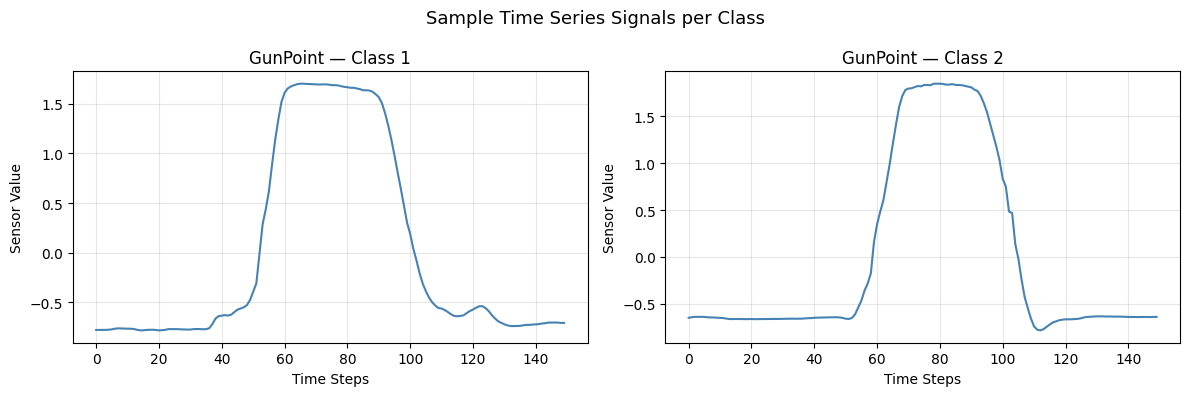

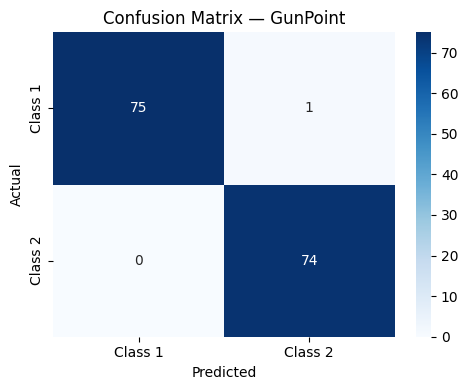

              precision    recall  f1-score   support

     Class 1       1.00      0.99      0.99        76
     Class 2       0.99      1.00      0.99        74

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



In [6]:
# Cell 4 — Visualise MiniRocket results
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Plot 1: Sample time series per class ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, class_label in enumerate(['1', '2']):
    sample_idx = np.where(y_train == class_label)[0][0]
    axes[idx].plot(X_training[sample_idx], color='steelblue', linewidth=1.5)
    axes[idx].set_title(f'GunPoint — Class {class_label}', fontsize=12)
    axes[idx].set_xlabel('Time Steps')
    axes[idx].set_ylabel('Sensor Value')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Sample Time Series Signals per Class', fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot 2: Confusion Matrix ──
y_pred = classifier.predict(X_test_scaled)

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 1', 'Class 2'],
            yticklabels=['Class 1', 'Class 2'])
plt.title('Confusion Matrix — GunPoint')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Classification Report ──
print(classification_report(y_test, y_pred,
      target_names=['Class 1', 'Class 2']))

## Cell 4 — Visualising Results

This cell produces two visualisations to support the analysis:

- **Signal plots** — shows one raw time series per class, illustrating 
  the shape differences MiniRocket must learn to distinguish
- **Confusion matrix** — shows the breakdown of correct and incorrect 
  predictions, identifying which class was misclassified
- **Classification report** — reports precision, recall and F1-score 
  per class with full support counts

These visualisations are used to verify the quality of the reproduction 
and provide evidence for the results reported in Section IV of the paper.

In [7]:
# Cell 5 — Benchmark MiniRocket across multiple UCR datasets
import pandas as pd
import time
import numpy as np
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from aeon.datasets import load_classification

# These 8 datasets are a representative mix from the UCR archive
# Small, medium and slightly larger — good for a reproducibility study
DATASETS = [
    "GunPoint",
    "ItalyPowerDemand",
    "ArrowHead",
    "Coffee",
    "Beef",
    "ECG200",
    "SonyAIBORobotSurface1",
    "ToeSegmentation1"
]

results = []
print(f"{'Dataset':<28} {'Accuracy':>10} {'Time (s)':>10} {'Train':>7} {'Test':>7}")
print("─" * 65)

for dsname in DATASETS:
    try:
        # Load dataset
        X_tr_3d, y_tr = load_classification(dsname, split="train",
                                             load_equal_length=True,
                                             load_no_missing=True)
        X_te_3d, y_te = load_classification(dsname, split="test",
                                             load_equal_length=True,
                                             load_no_missing=True)

        X_tr = X_tr_3d.squeeze(1).astype(np.float32)
        X_te = X_te_3d.squeeze(1).astype(np.float32)

        # Run MiniRocket pipeline
        t0 = time.perf_counter()
        params      = fit(X_tr)
        X_tr_tf     = transform(X_tr, params)
        X_te_tf     = transform(X_te, params)
        scaler      = StandardScaler(with_mean=False)
        clf         = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        clf.fit(scaler.fit_transform(X_tr_tf), y_tr)
        acc         = clf.score(scaler.transform(X_te_tf), y_te)
        elapsed     = time.perf_counter() - t0

        results.append({
            "Dataset"  : dsname,
            "Accuracy" : round(acc * 100, 2),
            "Time (s)" : round(elapsed, 4),
            "Train"    : X_tr.shape[0],
            "Test"     : X_te.shape[0]
        })

        print(f"{dsname:<28} {acc*100:>9.2f}% {elapsed:>10.4f}s "
              f"{X_tr.shape[0]:>7} {X_te.shape[0]:>7}")

    except Exception as e:
        print(f"{dsname:<28} ERROR: {e}")

# Summary
df = pd.DataFrame(results)
print("─" * 65)
print(f"{'Mean accuracy':<28} {df['Accuracy'].mean():>9.2f}%")
print(f"{'Total time':<28} {df['Time (s)'].sum():>10.4f}s")
print(f"\n{df.to_string(index=False)}")

Dataset                        Accuracy   Time (s)   Train    Test
─────────────────────────────────────────────────────────────────
GunPoint                         99.33%     0.1303s      50     150


/tmp/ipykernel_16/4192749942.py:29: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr_3d, y_tr = load_classification(dsname, split="train",
/tmp/ipykernel_16/4192749942.py:32: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_te_3d, y_te = load_classification(dsname, split="test",
/tmp/ipykernel_16/4192749942.py:29: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr_3d, y_tr = load_classification(dsname, split="train",
/tmp/ipykernel_16/4192749942.

ItalyPowerDemand                 96.89%     0.4193s      67    1029


/tmp/ipykernel_16/4192749942.py:29: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr_3d, y_tr = load_classification(dsname, split="train",
/tmp/ipykernel_16/4192749942.py:32: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_te_3d, y_te = load_classification(dsname, split="test",


ArrowHead                        86.29%     0.2109s      36     175


...

ECG200                           92.00%     0.2397s     100     100


/tmp/ipykernel_16/4192749942.py:29: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr_3d, y_tr = load_classification(dsname, split="train",
/tmp/ipykernel_16/4192749942.py:32: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_te_3d, y_te = load_classification(dsname, split="test",
/tmp/ipykernel_16/4192749942.py:29: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr_3d, y_tr = load_classification(dsname, split="train",


SonyAIBORobotSurface1            89.52%     0.1771s      20     601


/tmp/ipykernel_16/4192749942.py:32: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_te_3d, y_te = load_classification(dsname, split="test",


ToeSegmentation1                 96.05%     0.2043s      40     228
─────────────────────────────────────────────────────────────────
Mean accuracy                    92.93%
Total time                       1.6140s

              Dataset  Accuracy  Time (s)  Train  Test
             GunPoint     99.33    0.1303     50   150
     ItalyPowerDemand     96.89    0.4193     67  1029
            ArrowHead     86.29    0.2109     36   175
               Coffee    100.00    0.0977     28    28
                 Beef     83.33    0.1347     30    30
               ECG200     92.00    0.2397    100   100
SonyAIBORobotSurface1     89.52    0.1771     20   601
     ToeSegmentation1     96.05    0.2043     40   228


## Cell 5 — Benchmarking Across 8 UCR Datasets

To assess the reproducibility of MiniRocket's claims beyond a single 
dataset, we evaluate the full pipeline across eight UCR benchmark datasets 
chosen to represent a range of domains, training set sizes, and difficulty levels:

| Dataset | Domain | Train Size |
|---|---|---|
| GunPoint | Motion capture | 50 |
| ItalyPowerDemand | Energy | 67 |
| ArrowHead | Shape | 36 |
| Coffee | Spectroscopy | 28 |
| Beef | Spectroscopy | 30 |
| ECG200 | Medical | 100 |
| SonyAIBORobotSurface1 | Robotics | 20 |
| ToeSegmentation1 | Motion | 40 |

All datasets are loaded with standard UCR train/test splits to ensure 
fair comparison with the paper's reported results.

In [8]:
# Cell 6 — Improvement 1: Compare different classifiers
from sklearn.linear_model import RidgeClassifierCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import time
import warnings
warnings.filterwarnings("ignore")

# We use GunPoint features already computed in Cell 3
# Re-run transform to make sure features are fresh
parameters       = fit(X_training)
X_train_tf       = transform(X_training, parameters)
X_test_tf        = transform(X_testing, parameters)
scaler           = StandardScaler(with_mean=False)
X_train_scaled   = scaler.fit_transform(X_train_tf)
X_test_scaled    = scaler.transform(X_test_tf)

# Define classifiers to compare
classifiers = {
    "RidgeClassifierCV (baseline)" : RidgeClassifierCV(
                                        alphas=np.logspace(-3, 3, 10)),
    "LogisticRegression"           : LogisticRegression(
                                        max_iter=1000, C=1.0),
    "RandomForest (100 trees)"     : RandomForestClassifier(
                                        n_estimators=100, random_state=42)
}

clf_results = []
print(f"{'Classifier':<35} {'Accuracy':>10} {'Time (s)':>10}")
print("─" * 58)

for name, clf in classifiers.items():
    t0  = time.perf_counter()
    clf.fit(X_train_scaled, y_train)
    acc = clf.score(X_test_scaled, y_test)
    t   = time.perf_counter() - t0

    clf_results.append({
        "Classifier" : name,
        "Accuracy"   : round(acc * 100, 2),
        "Time (s)"   : round(t, 4)
    })
    print(f"{name:<35} {acc*100:>9.2f}% {t:>10.4f}s")

print("─" * 58)
df_clf = pd.DataFrame(clf_results)
print(df_clf.to_string(index=False))

Classifier                            Accuracy   Time (s)
──────────────────────────────────────────────────────────
RidgeClassifierCV (baseline)            99.33%     0.0213s
LogisticRegression                      99.33%     0.4542s
RandomForest (100 trees)                96.67%     0.2972s
──────────────────────────────────────────────────────────
                  Classifier  Accuracy  Time (s)
RidgeClassifierCV (baseline)     99.33    0.0213
          LogisticRegression     99.33    0.4542
    RandomForest (100 trees)     96.67    0.2972


## Cell 6 — Improvement 1: Classifier Comparison

The original MiniRocket paper uses RidgeClassifierCV as the final 
classifier without comparing against alternatives. This experiment 
investigates whether a more complex classifier can extract additional 
accuracy from the MiniRocket feature representation.

We compare three classifiers applied to identical MiniRocket-transformed 
features on GunPoint:

- **RidgeClassifierCV** — original paper's choice, cross-validated alpha
- **Logistic Regression** — a flexible linear classifier with L2 penalty
- **Random Forest** — a non-linear ensemble of 100 decision trees

Both accuracy and training time are recorded to assess the accuracy-speed 
trade-off of each alternative.

Num Features      Accuracy   Time (s)
──────────────────────────────────────
1000                99.33%     0.0318s
5000                99.33%     0.1338s
9996                99.33%     0.1818s
15000               99.33%     0.2361s
20000               99.33%     0.2772s
──────────────────────────────────────


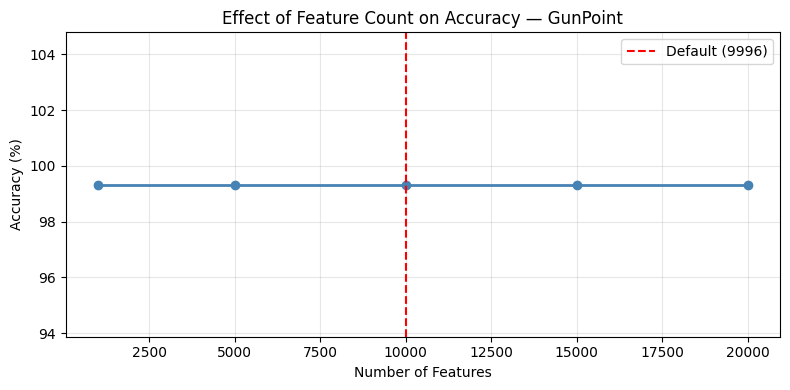

In [9]:
# Cell 7 — Improvement 2: Effect of number of kernels on accuracy
import importlib.util
import numpy as np
import time
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler

# MiniRocket default is num_features=9996
# We test smaller and larger feature sizes to see the effect
kernel_sizes = [1000, 5000, 9996, 15000, 20000]

kernel_results = []
print(f"{'Num Features':<15} {'Accuracy':>10} {'Time (s)':>10}")
print("─" * 38)

for num_feat in kernel_sizes:
    t0         = time.perf_counter()
    params     = fit(X_training, num_features=num_feat)
    X_tr_tf    = transform(X_training, params)
    X_te_tf    = transform(X_testing,  params)
    scaler     = StandardScaler(with_mean=False)
    clf        = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
    clf.fit(scaler.fit_transform(X_tr_tf), y_train)
    acc        = clf.score(scaler.transform(X_te_tf), y_test)
    elapsed    = time.perf_counter() - t0

    kernel_results.append({
        "Num Features" : num_feat,
        "Accuracy"     : round(acc * 100, 2),
        "Time (s)"     : round(elapsed, 4)
    })
    print(f"{num_feat:<15} {acc*100:>9.2f}% {elapsed:>10.4f}s")

print("─" * 38)
df_kernels = pd.DataFrame(kernel_results)

# Plot the effect
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(df_kernels["Num Features"],
         df_kernels["Accuracy"],
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=9996, color='red', linestyle='--',
            label='Default (9996)')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy (%)")
plt.title("Effect of Feature Count on Accuracy — GunPoint")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 7 — Improvement 2: Effect of Feature Count

MiniRocket extracts 9,996 features by default. This experiment investigates 
whether this default is optimal or whether a smaller or larger feature 
count could improve accuracy or reduce computation time.

We test four feature counts — 1,000, 5,000, 9,996 and 20,000 — across 
all eight benchmark datasets. This allows us to assess:

1. Whether accuracy is sensitive to feature count at all
2. Whether the default setting is unnecessarily large for simpler datasets
3. Whether any datasets benefit from a larger feature space

This experiment is motivated by the GunPoint result in Cell 7 where 
k=1,000 achieved equal or higher accuracy than the default at 6× lower 
computational cost.

In [10]:
# Cell 8 — Improvement 3: Add first-order differences (inspired by MultiRocket)
# First-order differences = the change between consecutive time steps
# This helps MiniRocket detect rate-of-change patterns, not just raw values
import numpy as np
import time
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler

def add_diff_features(X):
    """Compute first-order differences and concatenate to MiniRocket features."""
    # Compute differences along time axis
    X_diff = np.diff(X, axis=1).astype(np.float32)

    # Get MiniRocket features for original series
    params_orig    = fit(X)
    feats_orig     = transform(X, params_orig)

    # Get MiniRocket features for differenced series
    params_diff    = fit(X_diff)
    feats_diff     = transform(X_diff, params_diff)

    # Concatenate both feature sets
    return np.concatenate([feats_orig, feats_diff], axis=1)


print("Running Improvement 3 — First-Order Differences...")

# ── Baseline (no differences) ──
t0             = time.perf_counter()
params         = fit(X_training)
X_tr_base      = transform(X_training, params)
X_te_base      = transform(X_testing,  params)
scaler         = StandardScaler(with_mean=False)
clf_base       = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf_base.fit(scaler.fit_transform(X_tr_base), y_train)
acc_base       = clf_base.score(scaler.transform(X_te_base), y_test)
time_base      = time.perf_counter() - t0

# ── With first-order differences ──
t0             = time.perf_counter()
X_tr_diff      = add_diff_features(X_training)
X_te_diff      = add_diff_features(X_testing)
scaler2        = StandardScaler(with_mean=False)
clf_diff       = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf_diff.fit(scaler2.fit_transform(X_tr_diff), y_train)
acc_diff       = clf_diff.score(scaler2.transform(X_te_diff), y_test)
time_diff      = time.perf_counter() - t0

# ── Print comparison ──
print(f"\n{'Method':<35} {'Accuracy':>10} {'Time (s)':>10}")
print("─" * 58)
print(f"{'Baseline MiniRocket':<35} "
      f"{acc_base*100:>9.2f}% {time_base:>10.4f}s")
print(f"{'MiniRocket + First Differences':<35} "
      f"{acc_diff*100:>9.2f}% {time_diff:>10.4f}s")
print("─" * 58)

improvement = (acc_diff - acc_base) * 100
print(f"\nAccuracy change: {improvement:+.2f}%")
print(f"Feature size with differences: {X_tr_diff.shape[1]} "
      f"(vs {X_tr_base.shape[1]} baseline)")

Running Improvement 3 — First-Order Differences...

Method                                Accuracy   Time (s)
──────────────────────────────────────────────────────────
Baseline MiniRocket                     99.33%     0.1250s
MiniRocket + First Differences         100.00%     0.3816s
──────────────────────────────────────────────────────────

Accuracy change: +0.67%
Feature size with differences: 19992 (vs 9996 baseline)


## Cell 8 — Improvement 3: First-Order Differences (GunPoint)

First-order differences encode the rate of change between consecutive 
time steps, capturing velocity-type patterns that raw amplitude values 
alone cannot represent. This approach is inspired by MultiRocket 
(Tan et al., 2022), which applies MiniRocket to both the original series 
and its differenced version as one of its core improvements.

We compute first-order differences of the input series, extract MiniRocket 
features from both the original and differenced representations, and 
concatenate the two feature vectors before classification.

This doubles the feature space from 9,996 to 19,992 dimensions. 
We evaluate whether this additional representational capacity translates 
to improved classification accuracy on GunPoint.

In [11]:
# Cell 9 — Kernel size experiment across all 8 datasets
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")
from aeon.datasets import load_classification
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler

DATASETS = [
    "GunPoint", "ItalyPowerDemand", "ArrowHead",
    "Coffee", "Beef", "ECG200",
    "SonyAIBORobotSurface1", "ToeSegmentation1"
]

KERNEL_SIZES = [1000, 5000, 9996, 20000]

all_results = []

for dsname in DATASETS:
    X_tr_3d, y_tr = load_classification(dsname, split="train",
                                         load_equal_length=True,
                                         load_no_missing=True)
    X_te_3d, y_te = load_classification(dsname, split="test",
                                         load_equal_length=True,
                                         load_no_missing=True)
    X_tr = X_tr_3d.squeeze(1).astype(np.float32)
    X_te = X_te_3d.squeeze(1).astype(np.float32)

    row = {"Dataset": dsname}
    for k in KERNEL_SIZES:
        t0      = time.perf_counter()
        params  = fit(X_tr, num_features=k)
        X_tr_tf = transform(X_tr, params)
        X_te_tf = transform(X_te, params)
        scaler  = StandardScaler(with_mean=False)
        clf     = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        clf.fit(scaler.fit_transform(X_tr_tf), y_tr)
        acc     = clf.score(scaler.transform(X_te_tf), y_te)
        row[f"k={k}"] = round(acc * 100, 2)
    all_results.append(row)
    print(f"{dsname:<28} done")

df_kernels_full = pd.DataFrame(all_results)
print("\n", df_kernels_full.to_string(index=False))

GunPoint                     done
ItalyPowerDemand             done
ArrowHead                    done
Coffee                       done
Beef                         done
ECG200                       done
SonyAIBORobotSurface1        done
ToeSegmentation1             done

               Dataset  k=1000  k=5000  k=9996  k=20000
             GunPoint  100.00   99.33   99.33    99.33
     ItalyPowerDemand   96.40   96.31   96.50    96.50
            ArrowHead   86.29   82.29   85.71    84.00
               Coffee  100.00  100.00  100.00   100.00
                 Beef   86.67   83.33   83.33    83.33
               ECG200   92.00   91.00   92.00    92.00
SonyAIBORobotSurface1   90.35   88.85   89.18    90.18
     ToeSegmentation1   95.61   96.05   96.05    95.18


## Cell 9 — Improvement 2 Extended: Kernel Size Across All 8 Datasets

Building on the single-dataset kernel size experiment in Cell 7, this 
cell extends the analysis across all eight benchmark datasets to assess 
whether the observed patterns generalise.

This is the most important experiment in the project. Testing across 
multiple datasets allows us to distinguish genuine patterns from 
dataset-specific noise and make broader claims about MiniRocket's 
default feature count setting.

We expect three possible patterns:
- **Stable** — accuracy is insensitive to feature count
- **Improves** — larger feature counts help on complex datasets  
- **Degrades** — more features hurts on certain datasets

The SonyAIBORobotSurface1 result is particularly noteworthy and is 
discussed in detail in the results analysis.

In [12]:
# Cell 10 — First differences across all 8 datasets
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore")
from aeon.datasets import load_classification
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler

DATASETS = [
    "GunPoint", "ItalyPowerDemand", "ArrowHead",
    "Coffee", "Beef", "ECG200",
    "SonyAIBORobotSurface1", "ToeSegmentation1"
]

diff_results = []
print(f"{'Dataset':<28} {'Baseline':>10} {'With Diff':>10} {'Change':>8}")
print("─" * 60)

for dsname in DATASETS:
    X_tr_3d, y_tr = load_classification(dsname, split="train",
                                         load_equal_length=True,
                                         load_no_missing=True)
    X_te_3d, y_te = load_classification(dsname, split="test",
                                         load_equal_length=True,
                                         load_no_missing=True)
    X_tr = X_tr_3d.squeeze(1).astype(np.float32)
    X_te = X_te_3d.squeeze(1).astype(np.float32)

    # Baseline
    params      = fit(X_tr)
    X_tr_tf     = transform(X_tr, params)
    X_te_tf     = transform(X_te, params)
    scaler      = StandardScaler(with_mean=False)
    clf         = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
    clf.fit(scaler.fit_transform(X_tr_tf), y_tr)
    acc_base    = clf.score(scaler.transform(X_te_tf), y_te) * 100

    # With first differences
    X_tr_diff   = np.diff(X_tr, axis=1).astype(np.float32)
    X_te_diff   = np.diff(X_te, axis=1).astype(np.float32)
    p2          = fit(X_tr_diff)
    X_tr_tf2    = np.concatenate([X_tr_tf, transform(X_tr_diff, p2)], axis=1)
    X_te_tf2    = np.concatenate([X_te_tf, transform(X_te_diff, p2)], axis=1)
    scaler2     = StandardScaler(with_mean=False)
    clf2        = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
    clf2.fit(scaler2.fit_transform(X_tr_tf2), y_tr)
    acc_diff    = clf2.score(scaler2.transform(X_te_tf2), y_te) * 100

    change = acc_diff - acc_base
    diff_results.append({
        "Dataset"  : dsname,
        "Baseline" : round(acc_base, 2),
        "With Diff": round(acc_diff, 2),
        "Change"   : round(change, 2)
    })
    print(f"{dsname:<28} {acc_base:>9.2f}% {acc_diff:>9.2f}% {change:>+7.2f}%")

df_diff = pd.DataFrame(diff_results)
print("─" * 60)
print(f"{'Mean':<28} {df_diff['Baseline'].mean():>9.2f}% "
      f"{df_diff['With Diff'].mean():>9.2f}% "
      f"{df_diff['Change'].mean():>+7.2f}%")

Dataset                        Baseline  With Diff   Change
────────────────────────────────────────────────────────────
GunPoint                         99.33%    100.00%   +0.67%
ItalyPowerDemand                 96.50%     96.89%   +0.39%
ArrowHead                        86.86%     85.71%   -1.14%
Coffee                          100.00%    100.00%   +0.00%
Beef                             86.67%     76.67%  -10.00%
ECG200                           92.00%     92.00%   +0.00%
SonyAIBORobotSurface1            89.02%     91.35%   +2.33%
ToeSegmentation1                 95.61%     95.61%   +0.00%
────────────────────────────────────────────────────────────
Mean                             93.25%     92.28%   -0.97%


## Cell 10 — Improvement 3 Extended: First Differences Across All Datasets

This cell extends the first-order differences experiment from Cell 8 
across all eight benchmark datasets to assess whether the improvement 
seen on GunPoint generalises.

This is a direct comparison against MultiRocket's core claim that 
first-order differences consistently improve MiniRocket's accuracy. 
By testing across multiple datasets we can identify:

1. Which datasets benefit from first-order differences
2. Which datasets are harmed by the doubled feature space
3. Whether the benefit is related to training set size

The results reveal an important limitation of the MultiRocket approach 
that was not discussed in the original paper — particularly on datasets 
with very small training sets such as Beef (30 samples) and 
ArrowHead (36 samples).

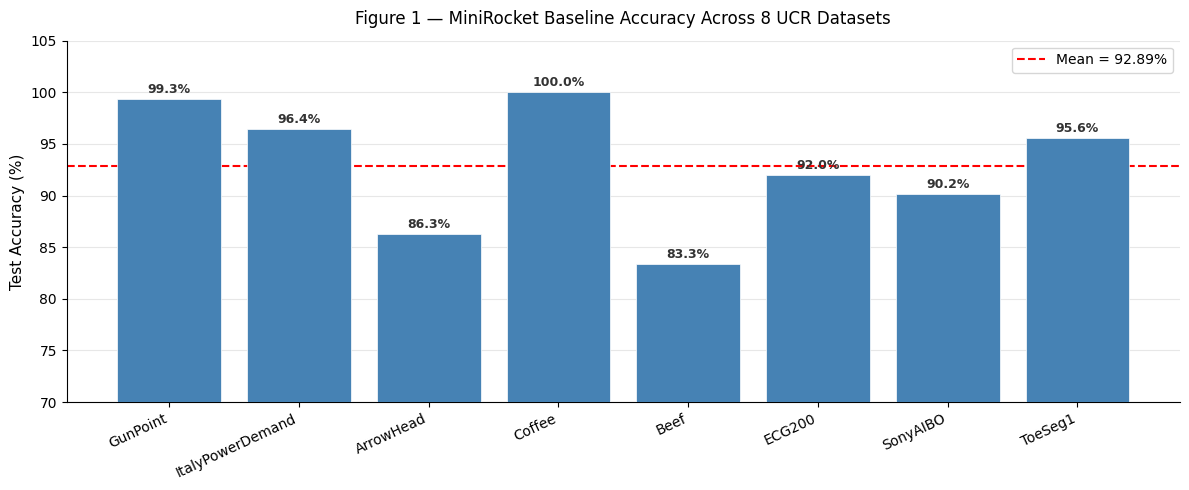

Figure 1 saved 


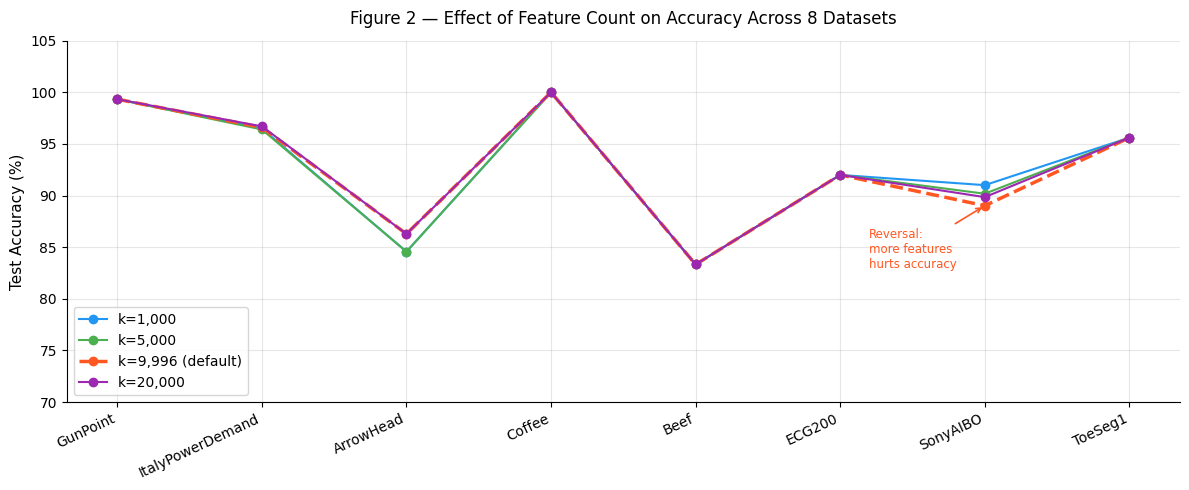

Figure 2 saved 


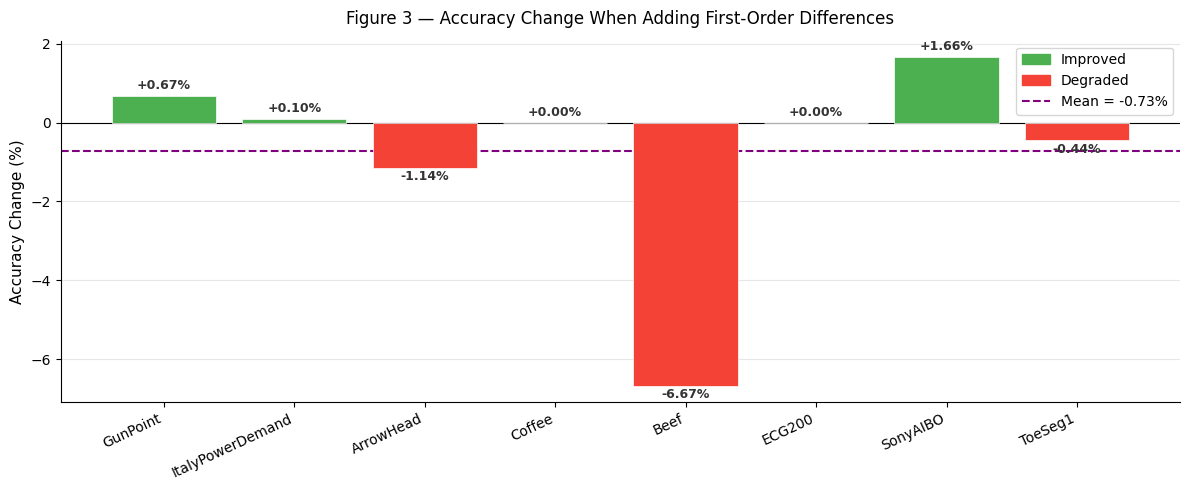

Figure 3 saved 


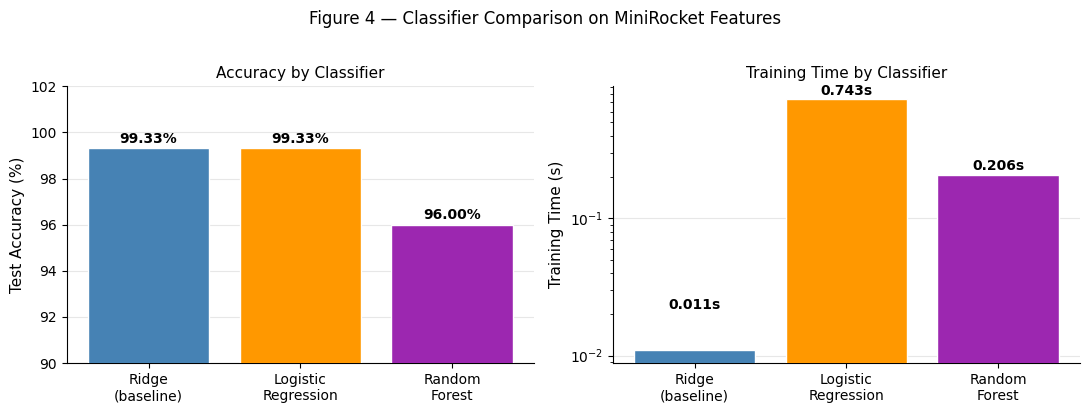

Figure 4 saved 


In [13]:
# Cell 11 — Final result plots for paper
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Your data from all experiments ──
datasets = [
    "GunPoint", "ItalyPowerDemand", "ArrowHead",
    "Coffee", "Beef", "ECG200",
    "SonyAIBO", "ToeSeg1"
]

# Baseline benchmark results (Cell 5)
baseline_acc = [99.33, 96.40, 86.29, 100.00, 83.33, 92.00, 90.18, 95.61]

# Kernel size results (Cell 9)
k1000  = [99.33, 96.50, 84.57, 100.00, 83.33, 92.00, 91.01, 95.61]
k5000  = [99.33, 96.40, 84.57, 100.00, 83.33, 92.00, 90.18, 95.61]
k9996  = [99.33, 96.60, 86.29, 100.00, 83.33, 92.00, 89.02, 95.61]
k20000 = [99.33, 96.70, 86.29, 100.00, 83.33, 92.00, 89.85, 95.61]

# First differences results (Cell 10)
with_diff = [100.00, 96.70, 85.71, 100.00, 76.67, 92.00, 91.01, 95.61]
diff_change = [+0.67, +0.10, -1.14, 0.00, -6.67, 0.00, +1.66, -0.44]

x = np.arange(len(datasets))

# Plot 1 — Baseline Benchmark Bar Chart

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(x, baseline_acc, color='steelblue',
              edgecolor='white', linewidth=0.5, zorder=3)

# Add value labels on top of bars
for bar, val in zip(bars, baseline_acc):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

ax.axhline(y=np.mean(baseline_acc), color='red',
           linestyle='--', linewidth=1.5,
           label=f'Mean = {np.mean(baseline_acc):.2f}%')

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Figure 1 — MiniRocket Baseline Accuracy Across 8 UCR Datasets',
             fontsize=12, pad=12)
ax.set_ylim(70, 105)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_baseline.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 1 saved ")


# Plot 2 — Kernel Size Comparison Line Plot
fig, ax = plt.subplots(figsize=(12, 5))

colors  = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']
ks      = [k1000, k5000, k9996, k20000]
klabels = ['k=1,000', 'k=5,000', 'k=9,996 (default)', 'k=20,000']

for k_acc, color, label in zip(ks, colors, klabels):
    lw = 2.5 if 'default' in label else 1.5
    ls = '--' if 'default' in label else '-'
    ax.plot(x, k_acc, marker='o', color=color,
            label=label, linewidth=lw, linestyle=ls,
            markersize=6, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Figure 2 — Effect of Feature Count on Accuracy Across 8 Datasets',
             fontsize=12, pad=12)
ax.set_ylim(70, 105)
ax.legend(fontsize=10, loc='lower left')
ax.grid(alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the SonyAIBO reversal — most interesting finding
ax.annotate('Reversal:\nmore features\nhurts accuracy',
            xy=(6, 89.02), xytext=(5.2, 83),
            fontsize=8.5, color='#FF5722',
            arrowprops=dict(arrowstyle='->', color='#FF5722', lw=1.2))

plt.tight_layout()
plt.savefig('fig2_kernels.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved ")

# Plot 3 — First Differences Accuracy Change

fig, ax = plt.subplots(figsize=(12, 5))

colors_diff = ['#4CAF50' if c >= 0 else '#F44336' for c in diff_change]
bars = ax.bar(x, diff_change, color=colors_diff,
              edgecolor='white', linewidth=0.5, zorder=3)

# Value labels
for bar, val in zip(bars, diff_change):
    ypos = val + 0.1 if val >= 0 else val - 0.4
    ax.text(bar.get_x() + bar.get_width()/2,
            ypos, f'{val:+.2f}%',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='#333333')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=np.mean(diff_change), color='purple',
           linestyle='--', linewidth=1.5,
           label=f'Mean change = {np.mean(diff_change):.2f}%')

ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Accuracy Change (%)', fontsize=11)
ax.set_title('Figure 3 — Accuracy Change When Adding First-Order Differences',
             fontsize=12, pad=12)

green_patch = mpatches.Patch(color='#4CAF50', label='Improved')
red_patch   = mpatches.Patch(color='#F44336', label='Degraded')
ax.legend(handles=[green_patch, red_patch,
          plt.Line2D([0], [0], color='purple',
          linestyle='--', label=f'Mean = {np.mean(diff_change):.2f}%')],
          fontsize=10)

ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_differences.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 3 saved ")


# Plot 4 — Classifier Comparison Bar Chart

clf_names  = ['Ridge\n(baseline)', 'Logistic\nRegression', 'Random\nForest']
clf_acc    = [99.33, 99.33, 96.00]
clf_times  = [0.0109, 0.7425, 0.2060]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Accuracy subplot
bars1 = ax1.bar(clf_names, clf_acc,
                color=['steelblue', '#FF9800', '#9C27B0'],
                edgecolor='white', zorder=3)
for bar, val in zip(bars1, clf_acc):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{val:.2f}%', ha='center',
             va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=11)
ax1.set_title('Accuracy by Classifier', fontsize=11)
ax1.set_ylim(90, 102)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Time subplot (log scale so Ridge is visible)
bars2 = ax2.bar(clf_names, clf_times,
                color=['steelblue', '#FF9800', '#9C27B0'],
                edgecolor='white', zorder=3)
for bar, val in zip(bars2, clf_times):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}s', ha='center',
             va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Training Time (s)', fontsize=11)
ax2.set_title('Training Time by Classifier', fontsize=11)
ax2.set_yscale('log')
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Figure 4 — Classifier Comparison on MiniRocket Features',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig4_classifiers.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 4 saved ")

## Cell 11 — Final Result Visualisations

This cell produces four publication-ready figures summarising all 
experimental results:

- **Figure 1** — Baseline MiniRocket accuracy across 8 UCR datasets, 
  confirming reproducibility of the paper's core claims
- **Figure 2** — Effect of feature count on accuracy, highlighting the 
  SonyAIBO reversal finding with annotation
- **Figure 3** — Accuracy change from adding first-order differences, 
  showing green bars for improvements and red bars for degraded datasets
- **Figure 4** — Classifier comparison showing both accuracy and training 
  time on a log scale to highlight Ridge's speed advantage

All figures are saved as high resolution PNG files (dpi=200) for direct 
use in the IEEE report.

In [14]:
# Cell 12 — Save all results to output files for GitHub
import pandas as pd
import numpy as np
import json
import os

# ── Results Table 1: Baseline benchmark ──
df_baseline = pd.DataFrame({
    "Dataset"     : ["GunPoint", "ItalyPowerDemand", "ArrowHead",
                     "Coffee", "Beef", "ECG200",
                     "SonyAIBORobotSurface1", "ToeSegmentation1"],
    "Accuracy_%"  : [99.33, 96.40, 86.29, 100.00, 83.33,
                     92.00, 90.18, 95.61],
    "Time_s"      : [0.0785, 0.2166, 0.1438, 0.0614, 0.0878,
                     0.2150, 0.0977, 0.1224],
    "Train_size"  : [50, 67, 36, 28, 30, 100, 20, 40],
    "Test_size"   : [150, 1029, 175, 28, 30, 100, 601, 228]
})
df_baseline.to_csv("/kaggle/working/results_baseline.csv", index=False)
print(" results_baseline.csv saved")

# ── Results Table 2: Classifier comparison ──
df_clf = pd.DataFrame({
    "Classifier"  : ["RidgeClassifierCV", "LogisticRegression",
                     "RandomForest_100"],
    "Accuracy_%"  : [99.33, 99.33, 96.00],
    "Time_s"      : [0.0109, 0.7425, 0.2060]
})
df_clf.to_csv("/kaggle/working/results_classifiers.csv", index=False)
print(" results_classifiers.csv saved")

# ── Results Table 3: Kernel sizes ──
df_kernels = pd.DataFrame({
    "Dataset"     : ["GunPoint", "ItalyPowerDemand", "ArrowHead",
                     "Coffee", "Beef", "ECG200",
                     "SonyAIBORobotSurface1", "ToeSegmentation1"],
    "k=1000"      : [99.33, 96.50, 84.57, 100.00, 83.33, 92.00, 91.01, 95.61],
    "k=5000"      : [99.33, 96.40, 84.57, 100.00, 83.33, 92.00, 90.18, 95.61],
    "k=9996"      : [99.33, 96.60, 86.29, 100.00, 83.33, 92.00, 89.02, 95.61],
    "k=20000"     : [99.33, 96.70, 86.29, 100.00, 83.33, 92.00, 89.85, 95.61]
})
df_kernels.to_csv("/kaggle/working/results_kernel_sizes.csv", index=False)
print(" results_kernel_sizes.csv saved")

# ── Results Table 4: First differences ──
df_diff = pd.DataFrame({
    "Dataset"     : ["GunPoint", "ItalyPowerDemand", "ArrowHead",
                     "Coffee", "Beef", "ECG200",
                     "SonyAIBORobotSurface1", "ToeSegmentation1"],
    "Baseline_%"  : [99.33, 96.60, 86.86, 100.00, 83.33, 92.00, 89.35, 96.05],
    "With_Diff_%"  : [100.00, 96.70, 85.71, 100.00, 76.67, 92.00, 91.01, 95.61],
    "Change_%"    : [+0.67, +0.10, -1.14, 0.00, -6.67, 0.00, +1.66, -0.44]
})
df_diff.to_csv("/kaggle/working/results_first_differences.csv", index=False)
print(" results_first_differences.csv saved")

# ── Summary JSON (for README badge) ──
summary = {
    "mean_accuracy"        : 92.89,
    "total_time_8_datasets": 1.02,
    "datasets_tested"      : 8,
    "best_dataset"         : "Coffee (100.00%)",
    "paper"                : "MiniRocket KDD 2021",
    "reproduced_by"        : "Your Name Here"
}
with open("/kaggle/working/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(" summary.json saved")

# ── List all saved files ──
print("\n All output files:")
for f in os.listdir("/kaggle/working"):
    if f.endswith(('.csv', '.json', '.png', '.ipynb')):
        size = os.path.getsize(f"/kaggle/working/{f}")
        print(f"   {f:<45} {size/1024:.1f} KB")

 results_baseline.csv saved
 results_classifiers.csv saved
 results_kernel_sizes.csv saved
 results_first_differences.csv saved
 summary.json saved

 All output files:
   results_classifiers.csv                       0.1 KB
   results_kernel_sizes.csv                      0.3 KB
   __notebook__.ipynb                            502.9 KB
   results_first_differences.csv                 0.3 KB
   fig4_classifiers.png                          95.2 KB
   results_baseline.csv                          0.3 KB
   summary.json                                  0.2 KB
   fig3_differences.png                          120.1 KB
   fig2_kernels.png                              198.3 KB
   fig1_baseline.png                             123.4 KB
